# Regridding NetCDF files to a reference grid for model comparison

This script regrids `.nc` files with spatial `x`, `y`, `lon(x, y)`, and `lat(x, y)` coordinates onto a reference grid: lon, lat 1D. This is necessary to compare data from different models.

### Libraries:

The following libraries and functions are required to run this script.

In [1]:
#Import libraries:

import xarray as xr #Read and work with netCDF files
import numpy as np #Work with arrays and perform numerical operations
import matplotlib.pyplot as plt #Create plots and visualizations
import cartopy.crs as ccrs #Work with cartographic projections and create maps
import sys
sys.path.append("..")# Allow the script to import files located one directory level above the current file
from utils.DestinyGridParameters import newlonlat_city, crop_curvilinear  # Import the function that defines the target grid for each city
import os # Work with folders and file paths
from pathlib import Path
import glob
import xesmf as xe

### Definition of global variables:

In the next cells there are defined the characteristics of the data to interpolate, for example the variable name, the model and the driving model, which the former takes the data from. Also, you can choose the interpolation method you want to use (you can consult xesmf.regridder library), and define your model time intervals for your given global warning level (GWL).

To run the notebook with different combinations of parameter values, use Papermill from the terminal. See `README_papermill.md` for detailed instructions.

In [2]:
#City name and data info:
variable = 'huss'
driving_model = 'NorESM2-MM'
scenario = 'historical'
member = 'r1i1p1f1'
institution = 'BCCR-UCAN'
model = 'WRF451R-CI4C'
version = 'v1-r1'
time_period = '1hr'
data_version = 'v20240710'
city_name='Prague' #'Paris', 'Barcelona', 'Prague'

In [3]:
#Interpolation method:
interpolation_method = 'bilinear'

# Define your Global Warming Level (GWL) years for the driving model:
year_init_GWL3 = {'NorESM2-MM': 2081}
year_end_GWL3 = {'NorESM2-MM': 2100}

In [4]:
# Obtaination of the domain from the city_name
if city_name == 'Paris' or city_name == 'Barcelona' or city_name == 'Prague':
    # domain = 'ALPX-3i' 
    domain = 'ALPX-3f'#For my data, the current version is called ALPX-3i.
elif city_name == 'Bergen' or city_name == 'Hamburg' or city_name == 'NewCastle':
    domain = 'NSEA-3i'

In the cell below, there are saved in a list the files that have the characteristics defined above.

In [5]:
# Find files with the characteristics specified above
data_directory = '../I4C_CPRCM_DATA/'
path_list_0 = sorted(glob.glob(f"{data_directory}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/*.nc"))

### Select the simulation years, excluding the spin-up period. 

You can comment out this section if only the valid simulation period is available. Modify the limits to select a different simulation time range (year_init_GWL3 and year_end_GWL3 variables).

In [6]:
path_list = []
for path_n in path_list_0:
    all_date = path_n.split("_")[11]
    year = int(all_date[:4])
    if scenario == 'evaluation' and year >= 2000 and year <= 2009:
        path_list.append(path_n)
        print(f"{year} has been appended")
    elif scenario == 'historical' and year >= 1995 and year <= 2014:
        path_list.append(path_n)
        print(f"{year} has been appended")
    elif scenario == 'ssp370' and year >= year_init_GWL3[driving_model] and year <= year_end_GWL3[driving_model]:
        path_list.append(path_n)
        print(f"{year} has been appended")

1995 has been appended
1996 has been appended
1997 has been appended
1998 has been appended
1999 has been appended
2000 has been appended
2001 has been appended
2002 has been appended
2003 has been appended
2004 has been appended
2005 has been appended
2006 has been appended
2007 has been appended
2008 has been appended
2009 has been appended
2010 has been appended
2011 has been appended
2012 has been appended
2013 has been appended
2014 has been appended


### Crop and interpolate the files in `file_list`, and save them in a single file

First, the target I4C grid and it's parameters are obtained for the selected city using the 'newlonlat_city' function defined in 'DestinyGridParameters.py' in the utils folder. These parameters are based on the city grids defined in the I4C GitHub repository and include the target longitude and latitude coordinates, domain limits, grid size, and grid spacing.

Each NetCDF file in file_list is then opened and cropped to an area extending one degree beyond the target city domain. This additional margin prevents the loss of boundary points during interpolation.

The cropped dataset is interpolated onto the target grid using bilinear interpolation. Other methods can be selected by changing interpolation_method in the variables cell, such as nearest_s2d, patch, conservative, or conservative_normed.

After interpolation, the additional one-degree margin is removed to retain only the target city domain. The resulting dataset from each file is added to the list results.

Finally, all interpolated datasets are concatenated along the time dimension into a single dataset.

In [7]:
## target grid:

#Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city_name)
#New_longitude and new_latitude already have the limits expanded

# Define the target grid as a dataset: Necessary for xESMF regridding
ds_out = xr.Dataset(coords={ "lon": ("lon", new_longitude), "lat": ("lat", new_latitude)})

##Source grid and interpolation weights: They are the same in all cases because all datasets share the same source and target grids.

#Read the file:
ds = xr.open_dataset(path_list[0])

#Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
city = crop_curvilinear(ds, x_first-1, xend+1, y_first-1, yend+1)

# Create the source grid dataset using the original coordinates
ds_in = xr.Dataset({"lon": city["lon"], "lat": city["lat"],})

#Define the regridder: It calculates the interpolation weights. 
regridder = xe.Regridder( ds_in, ds_out, method=interpolation_method, periodic=False, ignore_degenerate=True)

## Regrid all files: 
results=[]
for file in path_list:
    #Read the file:
    ds = xr.open_dataset(file)

    #Crop the dataset to the city area using the grid parameters obtained from the GitHub repository:
    city = crop_curvilinear(ds, x_first-1, xend+1, y_first-1, yend+1)

    #Aply the regridder
    ds_city_interp = regridder(city[[variable]])

    # Crop to the extra degree:
    city_interp = ds_city_interp.where((ds_city_interp.lon >= x_first) & (ds_city_interp.lon <= xend) &(ds_city_interp.lat >= y_first) & (ds_city_interp.lat <= yend),drop=True)

    #copy atributes:
    city_interp[variable].attrs = city[variable].attrs.copy()
    
    #save the interpolated file in the result's list
    results.append(city_interp)
## Concatenate all files along the time dimension and sort them chronologically
city_interp_all = xr.concat(results, dim="time").sortby("time")

/nfs/home/gmeteo/moralesi/prueba_servidor/Y/envs/netcdf/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


### Visualization for an example time:

The next three representations show the original data, the data after the first crop with a one-degree buffer around the boundaries, and the final result after interpolation. In the first and second figures, the grid is not regular, while in the final interpolated result it is regular.

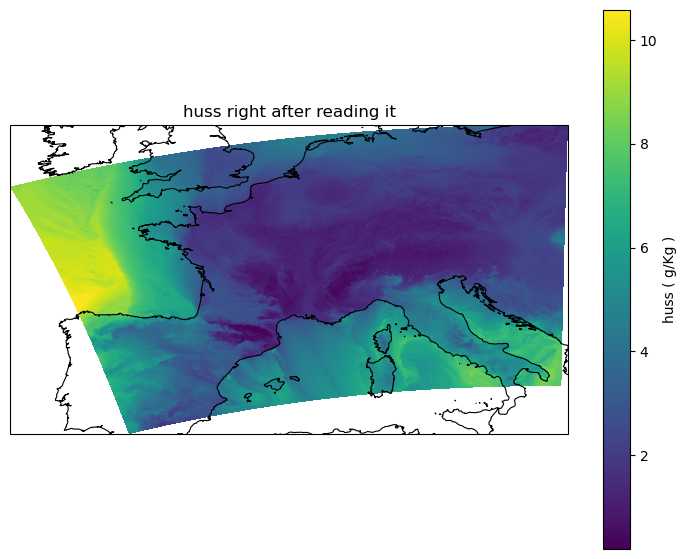

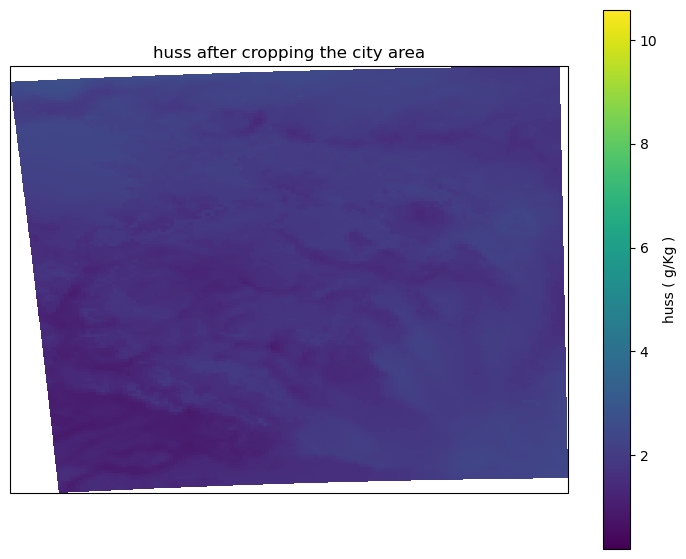

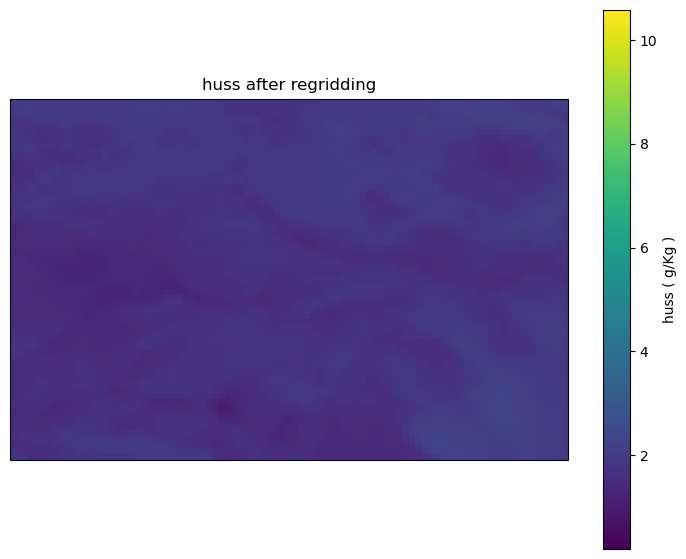

In [8]:
##Representations:

#Read the variables
T = ds[variable].isel(time=-1)*1000
T2 = city[variable].isel(time=-1)*1000
T3= city_interp_all[variable].isel(time=-1)*1000

#Obtain a unified colormap limit:
vmin = min(T.min(skipna=True).item(), T2.min(skipna=True).item(), T3.min(skipna=True).item())
vmax = max(T.max(skipna=True).item(), T2.max(skipna=True).item(), T3.max(skipna=True).item())

def representation(var, title):# Function to do representations below
    # Visualize the data with the silhouette of the continents using cartopy

    if var.attrs["units"] == "1":
        Variable_units = "g/Kg"
    else:
        Variable_units = var.attrs["units"]
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    m = ax.pcolormesh(var["lon"],var["lat"],var,vmin=vmin, vmax=vmax, shading="auto",transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.8)
    plt.colorbar(m, ax=ax, label=(f"{variable} ( {Variable_units} )"))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    plt.show()
representation(T, f"{variable} right after reading it")
representation(T2, f"{variable} after cropping the city area")
representation(T3, f"{variable} after regridding")

It can be seen that the boundaries become regular after interpolation, while the spatial structure of the variable remains unchanged.

### You can save the result uncommenting the code below:

In [9]:
# # path_save+"/"+base_name+'_'+city_name+"_cropped_interpolated"+'.nc')# Define the path where the file will be saved:
# path_save = '../utils/data'#It save the data file in a folder called data in your current directory
# os.makedirs(path_save, exist_ok = True)#It creates folders indicated in path_save if they doesn't exist

# #Save the cropped and interpolated dataset (city_interp) as a new netCDF file in the above directory:
# base_name = Path(path_list[0]).stem.rsplit("_", 1)[0] #It takes the file name without the time period
# city_interp_all.to_netcdf(path_save+"/"+base_name+'_'+city_name+"_cropped_interpolated"+'.nc')